In [15]:
pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Настройки печати
np.set_printoptions(precision=3, suppress=True)

In [18]:
# softmax для вектора
def softmax(scores):
    scores = np.asarray(scores, dtype=float)
    max_score = np.max(scores)
    exp_scores = np.exp(scores - max_score)
    denom = np.sum(exp_scores)
    return exp_scores / denom

In [19]:
# softmax по строкам для матрицы
def softmax_rows(data):
    # Softmax для данных в N x N
    max_per_row = np.max(data, axis=1, keepdims=True)
    exp_values = np.exp(data - max_per_row)
    denom = np.sum(exp_values, axis=1, keepdims=True)
    return exp_values / denom

In [20]:
# Генерация данных для N=3, D=5 как в 7.1
np.random.seed(3)
N = 3
D = 5
allx = []
for n in range(N):
    xn = np.random.normal(size=(D, 1))
    allx.append(xn)
print("xn для N=3:")
for i, x in enumerate(allx):
    print(f"x{i+1} shape {x.shape}, x.T\n{x.T}")

xn для N=3:
x1 shape (5, 1), x.T
[[ 1.789  0.437  0.096 -1.863 -0.277]]
x2 shape (5, 1), x.T
[[-0.355 -0.083 -0.627 -0.044 -0.477]]
x3 shape (5, 1), x.T
[[-1.314  0.885  0.881  1.71   0.05 ]]


In [21]:
np.random.seed(0)
omegaq = np.random.normal(size=(D, D))
omegak = np.random.normal(size=(D, D))
omegav = np.random.normal(size=(D, D))
betaq = np.random.normal(size=(D, 1))
betak = np.random.normal(size=(D, 1))
betav = np.random.normal(size=(D, 1))

In [22]:
print("\nomegaq shape", omegaq.shape)
print("omegak shape", omegak.shape)
print("omegav shape", omegav.shape)
print("betaq shape", betaq.shape)
print("betak shape", betak.shape)
print("betav shape", betav.shape)


omegaq shape (5, 5)
omegak shape (5, 5)
omegav shape (5, 5)
betaq shape (5, 1)
betak shape (5, 1)
betav shape (5, 1)


In [23]:
# Вычисление Q, K, V
allqueries = []
allkeys = []
allvalues = []
for x in allx:
    query = omegaq @ x + betaq  # D x 1
    key = omegak @ x + betak    # D x 1
    value = omegav @ x + betav  # D x 1
    allqueries.append(query)
    allkeys.append(key)
    allvalues.append(value)

In [24]:
print("\nqn, kn, vn:")
for i, (q, k, v) in enumerate(zip(allqueries, allkeys, allvalues)):
    print(f"n={i} q shape {q.shape}, k shape {k.shape}, v shape {v.shape}")


qn, kn, vn:
n=0 q shape (5, 1), k shape (5, 1), v shape (5, 1)
n=1 q shape (5, 1), k shape (5, 1), v shape (5, 1)
n=2 q shape (5, 1), k shape (5, 1), v shape (5, 1)


In [27]:
# Self-attention скалярный способ
allxprime = []
allattentions = []
for n in range(N):
    qn = allqueries[n]  # D x 1
    en = []
    for m in range(N):
        km = allkeys[m]  # D x 1
        # Иизвлечение скалярного значения из (1,1) массива
        dotproduct = float((qn.T @ km).item())  # или (qn.T @ km)[0,0]
        en.append(dotproduct)
    en = np.array(en)  # [N]
    alphan = softmax(en)  # [N]
    allattentions.append(alphan)
    
    xprimen = np.zeros((D, 1))
    for m in range(N):
        vm = allvalues[m]  # D x 1
        xprimen += alphan[m] * vm
    allxprime.append(xprimen)

print("\nxn' (скалярный способ):")
for i, xp in enumerate(allxprime):
    print(f"x'{i+1} shape {xp.shape}, xp.T\n{xp.T}")



xn' (скалярный способ):
x'1 shape (5, 1), xp.T
[[ 0.945 -0.161 -3.273 -3.126 -0.876]]
x'2 shape (5, 1), xp.T
[[ 2.622  3.286  1.55  -0.78   4.714]]
x'3 shape (5, 1), xp.T
[[ 2.097  0.692 -0.528 -1.664 -0.29 ]]


In [ ]:
# Матричная версия self-attention
def self_attention_matrix(allx, omegaq, omegak, omegav, betaq, betak, betav):
    D = allx[0].shape[0]
    N = len(allx)
    
    # X: D x N
    X = np.zeros((D, N))
    for n, x in enumerate(allx):
        X[:, n] = np.squeeze(x)
    
    ones_row = np.ones((1, N))  # 1 x N
    
    # Q = omegaq @ X + betaq @ ones_row : D x N
    Q = omegaq @ X + np.matmul(betaq, ones_row)
    # K = omegak @ X + betak @ ones_row : D x N
    K = omegak @ X + np.matmul(betak, ones_row)
    # V = omegav @ X + betav @ ones_row : D x N
    V = omegav @ X + np.matmul(betav, ones_row)
    
    # E = Q.T @ K : N x N
    E = K.T @ Q  # В оригинале Q.T @ K, но по формуле qn^T km, так что K.T @ Q для матрицы (поскольку qn - столбцы Q)
    # В описании 3.3 enm = qn km = qn^T km (скаляр), для матрицы E_{n,m} = q_n^T k_m, так что E = Q^T K (N x D * D x N = N x N)
    # В коде оригинальном E = Q.T @ K
    E = Q.T @ K
    
    # A = softmax(E) : N x N
    A = softmax_rows(E)
    
    # X' = V @ A.T : D x N
    Xprime = V @ A.T
    
    return Xprime, A

Xprimemat, Amat = self_attention_matrix(allx, omegaq, omegak, omegav, betaq, betak, betav)

print("\nX' matrix shape", Xprimemat.shape)
print("A shape", Amat.shape)

Xprimescalar = np.hstack(allxprime)  # D x N
print("\nСравнение X':")
for n in range(N):
    print(f"n={n}")
    print("scalar:", Xprimescalar[:, n])
    print("matrix:", Xprimemat[:, n])
    print()


X' matrix shape (5, 3)
A shape (3, 3)

Сравнение X':
n=0
scalar: [ 0.945 -0.161 -3.273 -3.126 -0.876]
matrix: [ 0.945 -0.161 -3.273 -3.126 -0.876]

n=1
scalar: [ 2.622  3.286  1.55  -0.78   4.714]
matrix: [ 2.622  3.286  1.55  -0.78   4.714]

n=2
scalar: [ 2.097  0.692 -0.528 -1.664 -0.29 ]
matrix: [ 2.097  0.692 -0.528 -1.664 -0.29 ]



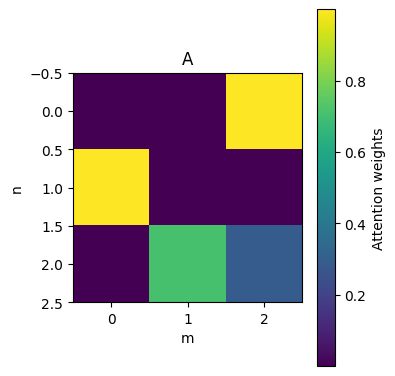

In [30]:
# Визуализация A
plt.figure(figsize=(4, 4))
plt.imshow(Amat, cmap='viridis')
plt.colorbar(label='Attention weights')
plt.xlabel('m')
plt.ylabel('n')
plt.title('A')
plt.tight_layout()
plt.show()

In [31]:
# Задача 7.2: Scaled dot-product attention, enm_scaled = (qn^T km) / sqrt(D)
def scaled_self_attention_matrix(allx, omegaq, omegak, omegav, betaq, betak, betav):
    D = allx[0].shape[0]
    N = len(allx)
    
    X = np.zeros((D, N))
    for n, x in enumerate(allx):
        X[:, n] = np.squeeze(x)
    
    ones_row = np.ones((1, N))
    
    Q = omegaq @ X + np.matmul(betaq, ones_row)
    K = omegak @ X + np.matmul(betak, ones_row)
    V = omegav @ X + np.matmul(betav, ones_row)
    
    # E_scaled = (Q^T K) / sqrt(D)
    scale = 1.0 / np.sqrt(D)
    E_scaled = scale * (Q.T @ K)
    
    A_scaled = softmax_rows(E_scaled)
    
    Xprime_scaled = V @ A_scaled.T
    
    return Xprime_scaled, A_scaled

Xprime_scaled, A_scaled = scaled_self_attention_matrix(allx, omegaq, omegak, omegav, betaq, betak, betav)

print("X' scaled shape", Xprime_scaled.shape)
print("A scaled:\n", A_scaled)

# Сравнение с оригиналом
print("\nРазница в X':")
print(np.abs(Xprimemat - Xprime_scaled).max())

X' scaled shape (5, 3)
A scaled:
 [[0.001 0.011 0.989]
 [0.988 0.012 0.   ]
 [0.046 0.571 0.383]]

Разница в X':
0.3188849674306208


In [33]:
# Задача 7.3: L1-норма весов softmax для каждой строки xn'
print("L1-норма строк A (оригинал):")
for n in range(N):
    l1_norm = np.sum(np.abs(Amat[n, :]))
    print(f"Строка {n}: {l1_norm:.6f}")

print("\nL1-норма строк A_scaled:")
for n in range(N):
    l1_norm_scaled = np.sum(np.abs(A_scaled[n, :]))
    print(f"Строка {n}: {l1_norm_scaled:.6f}")

L1-норма строк A (оригинал):
Строка 0: 1.000000
Строка 1: 1.000000
Строка 2: 1.000000

L1-норма строк A_scaled:
Строка 0: 1.000000
Строка 1: 1.000000
Строка 2: 1.000000
